# 힌남노 발생 당시 ERA5 analysis 그리는 코드

In [24]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from datetime import timedelta
from datetime import datetime

import matplotlib.pyplot as plt

# 전역 폰트 설정
plt.rcParams.update({
    'font.size': 12,          # 기본 폰트 크기
    'axes.titlesize': 18,     # ax.set_title() 크기
    'axes.labelsize': 16,     # 축 이름(label) 크기
    'xtick.labelsize': 14,    # x축 눈금 숫자 크기
    'ytick.labelsize': 14,    # y축 눈금 숫자 크기
    'legend.fontsize': 14,    # 범례 크기
    'figure.titlesize': 20    # 전체 그림 제목 크기
})
# GL 스타일 설정 (눈금 숫자 크기)
GL_STYLE = {'size': 14}

storm_year = 2022
storm_name = 'Hinnamnor'

## 힌남노 IBTrACS에서 JTWC 데이터 불러오기

In [26]:
tc_total_ds = xr.open_dataset(rf'/home1/jek/Pangu-Weather/input_data/IBTrACS.WP.v04r01.nc')
tc_ds = tc_total_ds.where((tc_total_ds['season'] == storm_year), drop=True)
tc_ds['name_str'] = tc_ds['name'].str.decode('utf-8').str.strip()

tc_ds = tc_ds.where(tc_ds['name_str'].str.upper() == storm_name.upper(), drop=True)
storm_lat, storm_lon, storm_mslp, storm_time, storm_speed, storm_type = tc_ds['usa_lat'][0].values.astype(np.float32), tc_ds['usa_lon'][0].values.astype(np.float32), tc_ds['usa_pres'][0].values.astype(np.float32), tc_ds['iso_time'][0].values.astype('datetime64').astype(datetime), tc_ds['usa_wind'][0].values.astype(np.float32), tc_ds['nature'][0].values.astype('str')
if any(lon < 0 for lon in storm_lon):
    storm_lon = [lon + 360 if lon < 0 else lon for lon in storm_lon]
storm_lon = np.array(storm_lon)

idx_mask = ~np.isnan(storm_lon)
storm_lat, storm_lon, storm_mslp, storm_time, storm_speed, storm_type = storm_lat[idx_mask], storm_lon[idx_mask], storm_mslp[idx_mask], storm_time[idx_mask], storm_speed[idx_mask], storm_type[idx_mask]


## 그릴 dataset 준비

In [27]:
var = 'z'

ds = xr.load_dataset(f"/data06/ERA5/hourly/{var}/ERA5_{var}_202208.nc")

### 200 hPa Geopotential height

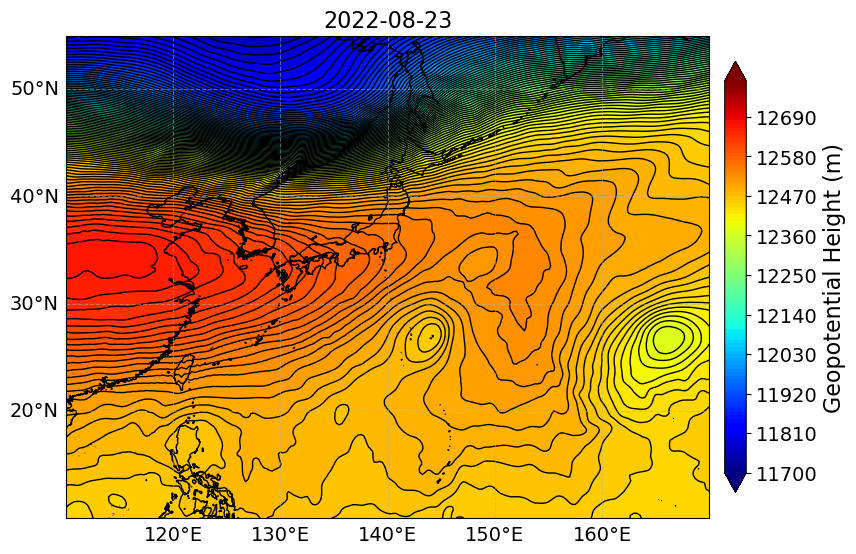

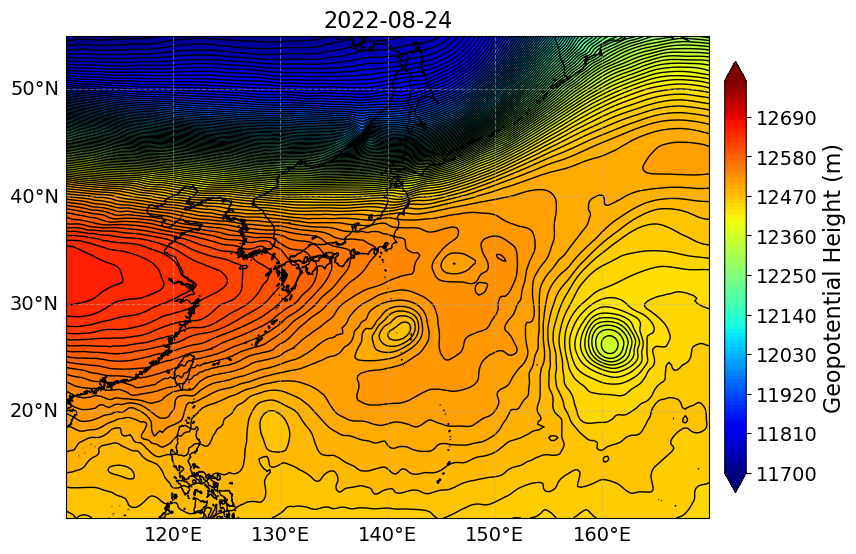

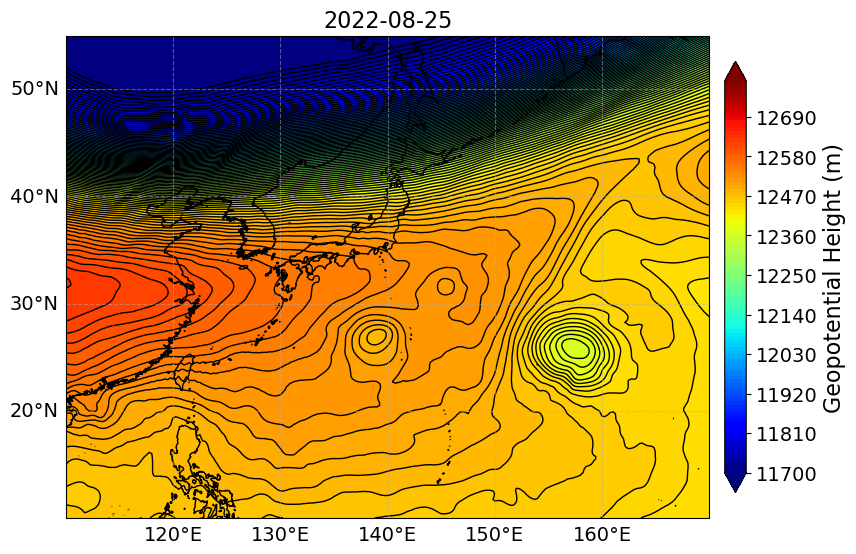

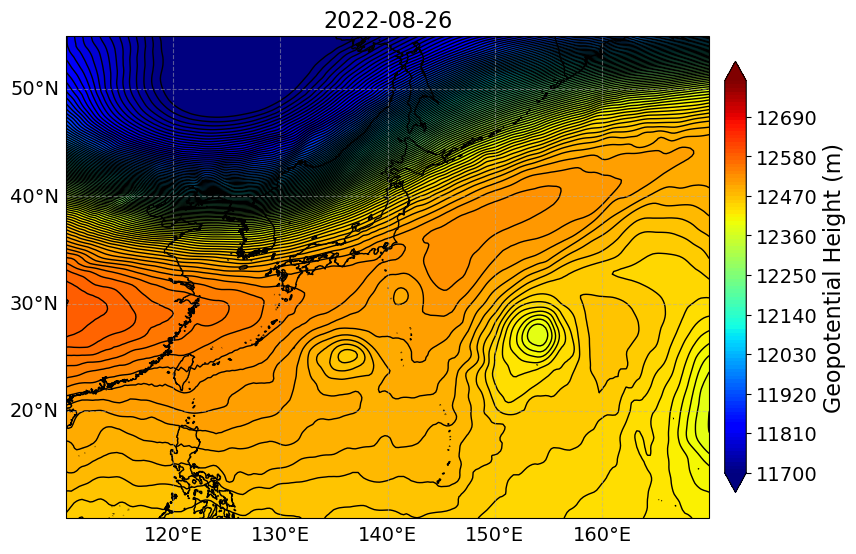

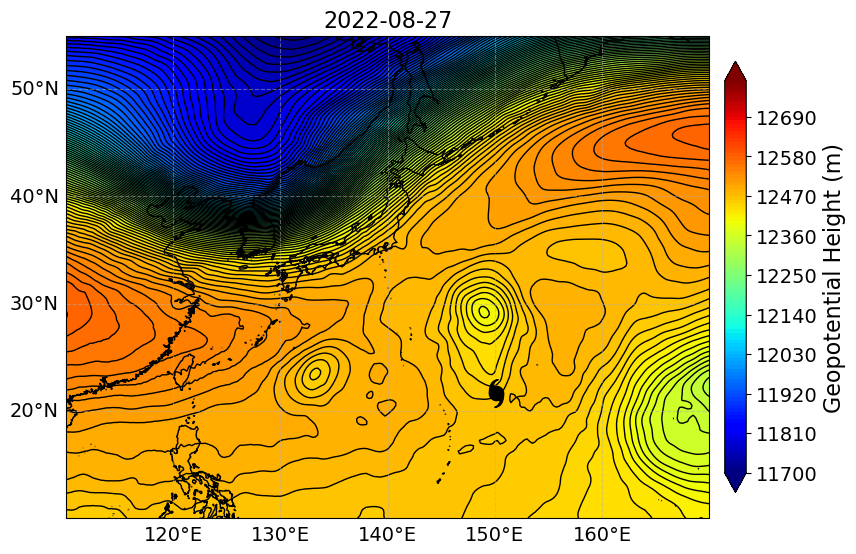

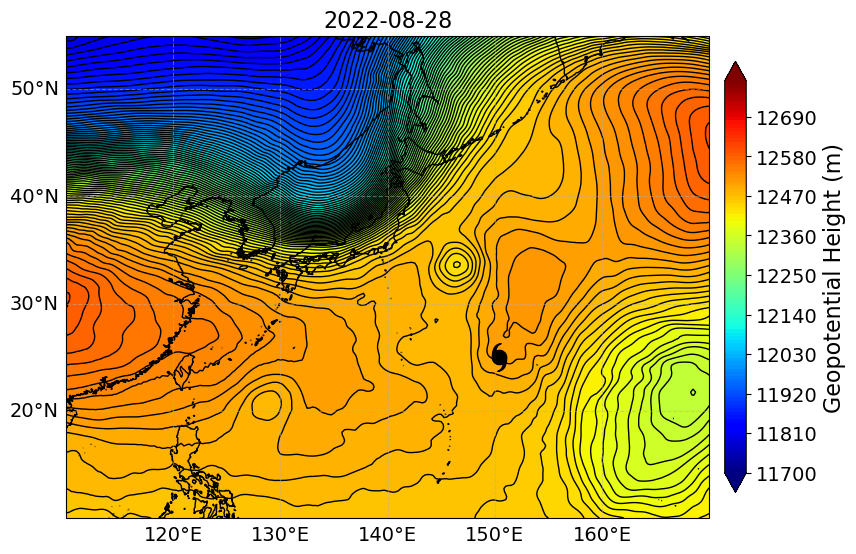

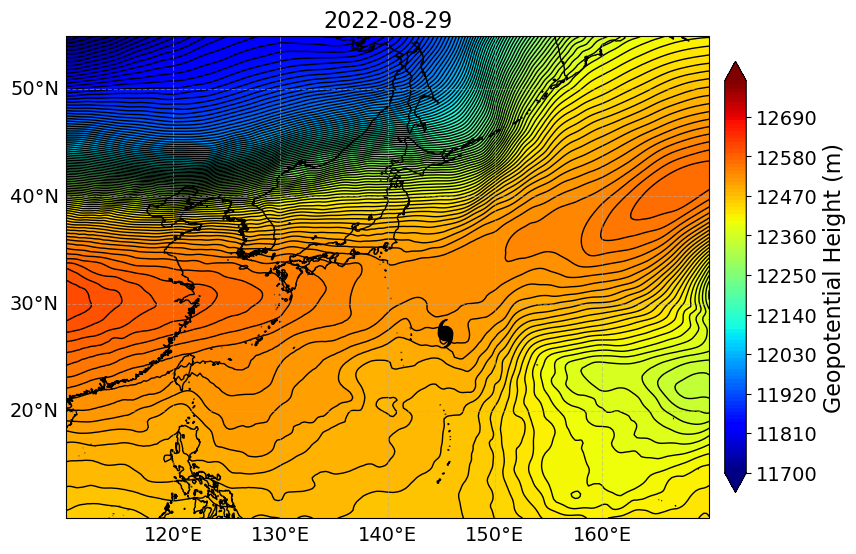

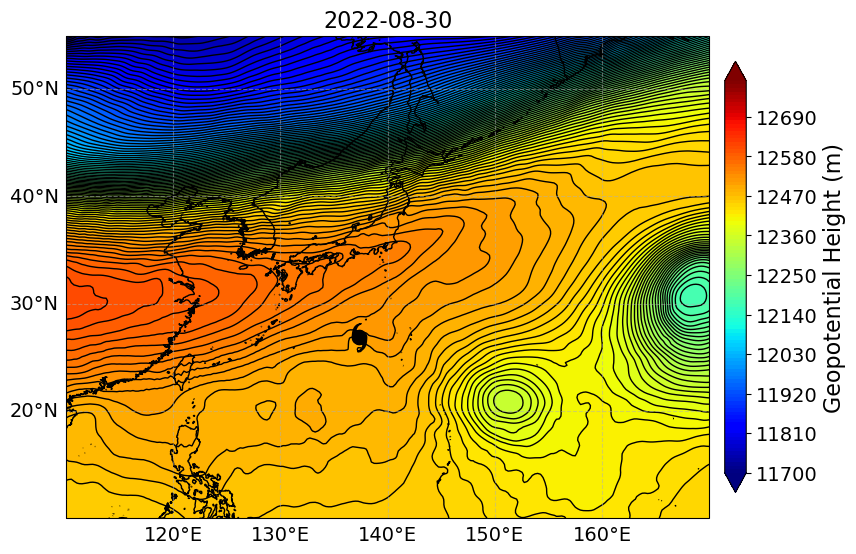

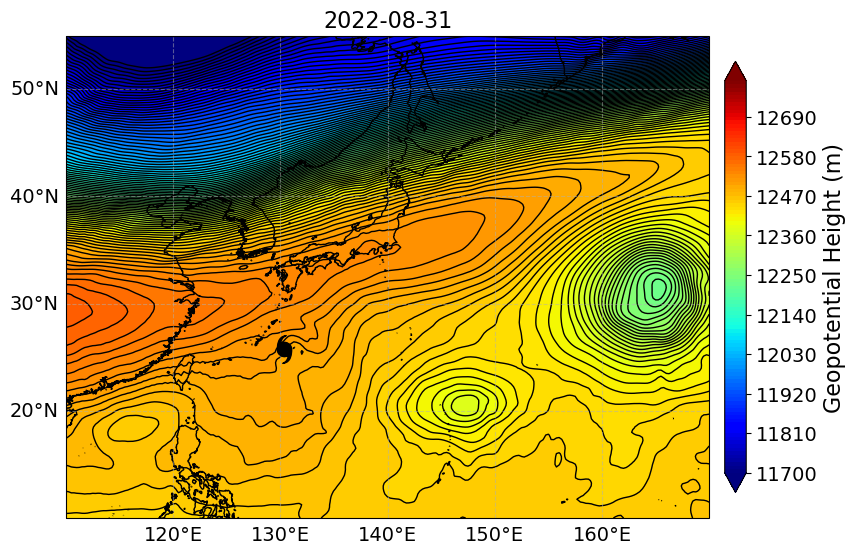

In [46]:
import datetime
import tcmarkers
G = 9.80665
level = 200

ds_part = ds[var].sel(pressure_level=level).sel(latitude=slice(55, 10), longitude=slice(110, 170))/G
lon_grid, lat_grid = np.meshgrid(ds_part.longitude.values, ds_part.latitude.values)

key_time = datetime.datetime(2022, 8, 23, 0)
for i in range(9):
    analysis_time = key_time + timedelta(days = i)
    fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree(0)})
    ax.coastlines("10m")
    ax.set_extent([110, 170, 10, 55], crs=ccrs.PlateCarree(0))

    # Geopotential height contour
    cf_ax = ax.contourf(lon_grid, lat_grid, ds_part.sel(valid_time = analysis_time), levels = np.arange(11700, 12800, 10), cmap='jet', transform=ccrs.PlateCarree(), linewidths=1, extend = 'both')
    c_ax = ax.contour(lon_grid, lat_grid, ds_part.sel(valid_time = analysis_time), levels = np.arange(11700, 12800, 10), colors='black', transform=ccrs.PlateCarree(), linewidths=1)
    plt.colorbar(cf_ax, ax = ax, label='Geopotential Height (m)', shrink=0.7, pad=0.02)
    ax.set_title(f'{analysis_time.strftime("%Y-%m-%d")}', fontsize = 16)

    # Draw storm location
    hin_lon, hin_lat = storm_lon[storm_time == analysis_time], storm_lat[storm_time == analysis_time]
    ax.scatter(hin_lon, hin_lat, color='black', s=100, marker=tcmarkers.HU, transform=ccrs.PlateCarree(), label=f'{storm_name} Location', zorder = 100)
    
    # lon, lat line drawer
    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, alpha = 0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xlocator = mticker.FixedLocator(np.arange(-180, 171, 10))
    gl.ylocator = mticker.FixedLocator(np.arange(10, 56, 10))
    gl.xlabel_style = GL_STYLE
    gl.ylabel_style = GL_STYLE
    plt.show()


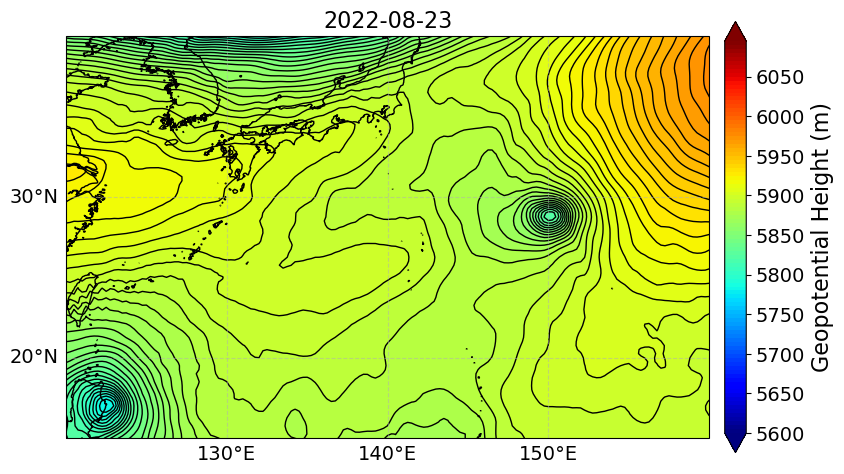

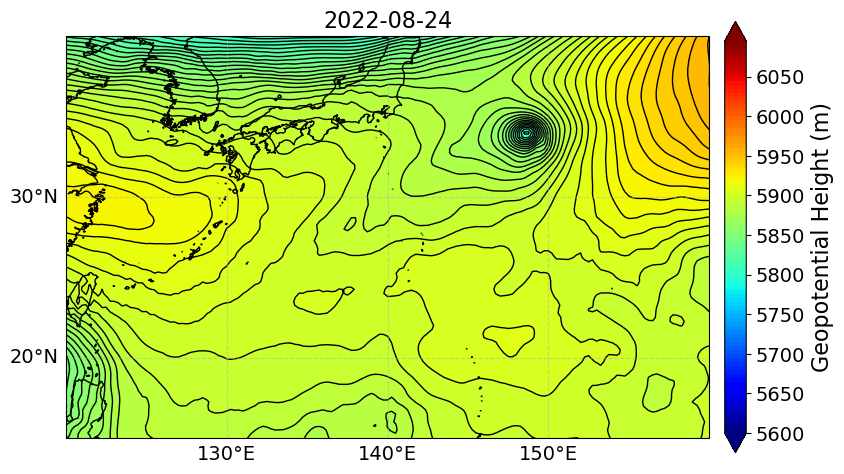

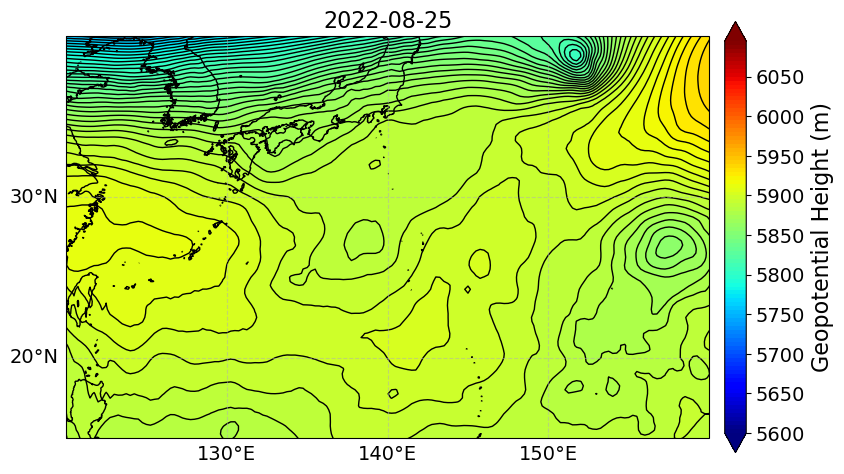

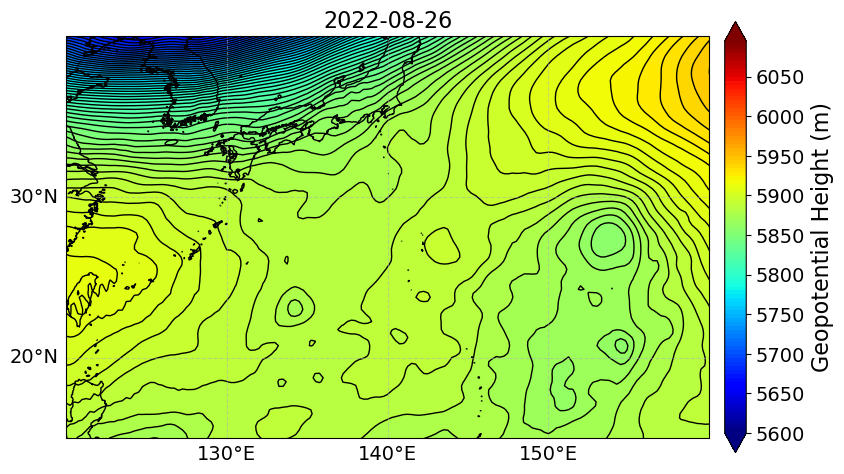

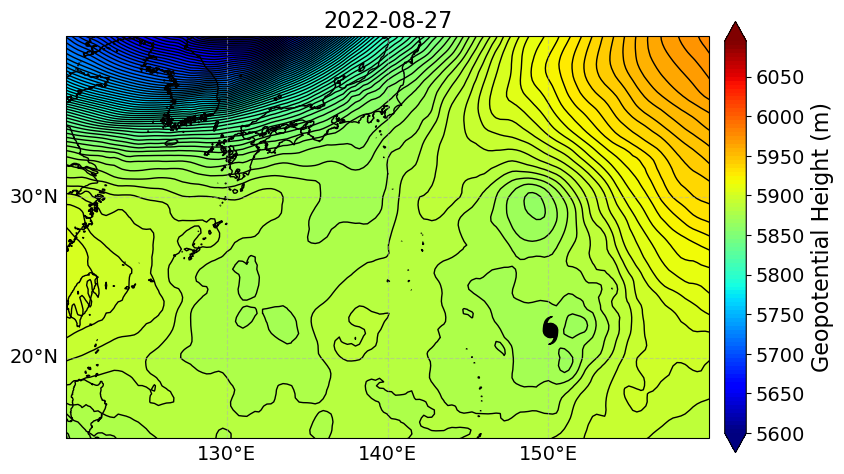

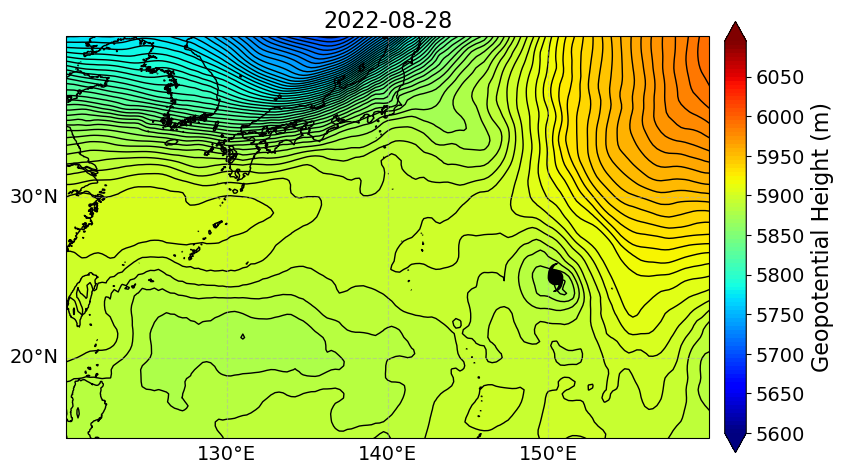

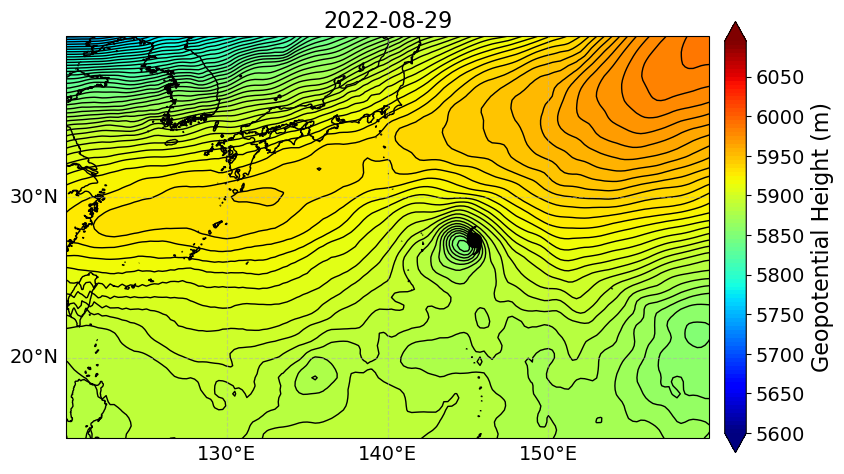

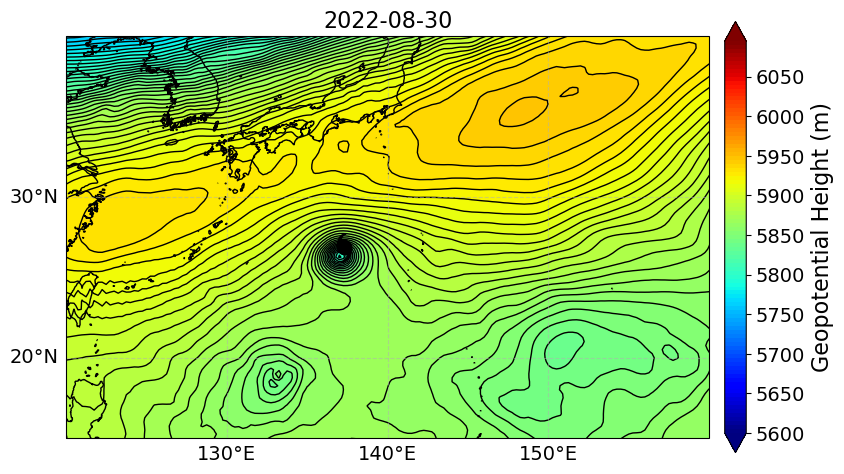

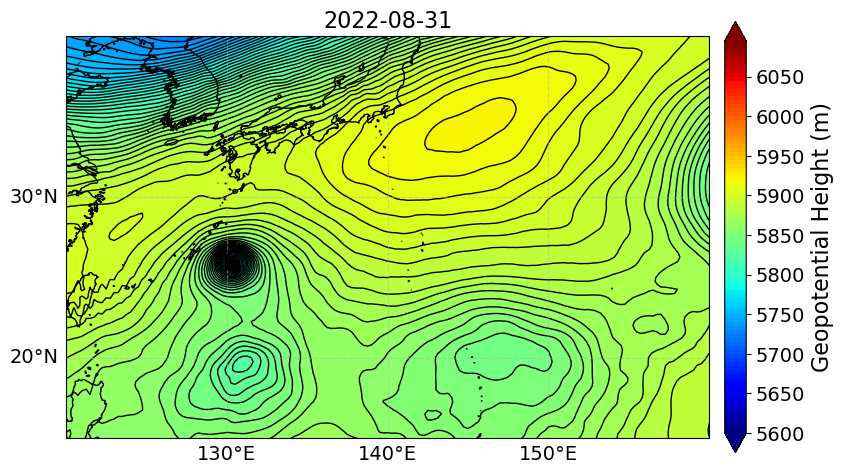

In [ ]:
import datetime
import tcmarkers
G = 9.80665
level = 500
# level = 850

ds_part = ds[var].sel(pressure_level=level).sel(latitude=slice(55, 10), longitude=slice(110, 170))/G
lon_grid, lat_grid = np.meshgrid(ds_part.longitude.values, ds_part.latitude.values)

key_time = datetime.datetime(2022, 8, 23, 0)
for i in range(9):
    analysis_time = key_time + timedelta(days = i)
    fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree(0)})
    ax.coastlines("10m")
    # ax.set_extent([110, 170, 10, 55], crs=ccrs.PlateCarree(0))
    ax.set_extent([120, 160, 15, 40], crs=ccrs.PlateCarree(0))

    # Geopotential height contour
    cf_ax = ax.contourf(lon_grid, lat_grid, ds_part.sel(valid_time = analysis_time), levels = np.arange(5400, 6100, 5), cmap='jet', transform=ccrs.PlateCarree(), linewidths=1, extend='both')
    c_ax = ax.contour(lon_grid, lat_grid, ds_part.sel(valid_time = analysis_time), levels = np.arange(5400, 6100, 5), colors='black', transform=ccrs.PlateCarree(), linewidths=1)
    # cf_ax = ax.contourf(lon_grid, lat_grid, ds_part.sel(valid_time = analysis_time), levels = np.arange(1200, 1700, 10), cmap='jet', transform=ccrs.PlateCarree(), linewidths=1, extend='both')
    # c_ax = ax.contour(lon_grid, lat_grid, ds_part.sel(valid_time = analysis_time), levels = np.arange(1200, 1700, 10), colors='black', transform=ccrs.PlateCarree(), linewidths=1)
    plt.colorbar(cf_ax, ax = ax, label='Geopotential Height (m)', shrink=0.7, pad=0.02)
    ax.set_title(f'{analysis_time.strftime("%Y-%m-%d")}', fontsize = 16)

    # Draw storm location
    hin_lon, hin_lat = storm_lon[storm_time == analysis_time], storm_lat[storm_time == analysis_time]
    ax.scatter(hin_lon, hin_lat, color='black', s=100, marker=tcmarkers.HU, transform=ccrs.PlateCarree(), label=f'{storm_name} Location', zorder = 100)
    
    # lon, lat line drawer
    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, alpha = 0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xlocator = mticker.FixedLocator(np.arange(-180, 171, 10))
    gl.ylocator = mticker.FixedLocator(np.arange(10, 56, 10))
    gl.xlabel_style = GL_STYLE
    gl.ylabel_style = GL_STYLE
    plt.show()


In [5]:
var = 't'

ds = xr.load_dataset(f"/data06/ERA5/hourly/{var}/ERA5_{var}_202208.nc")

/home1/jek/miniconda3/envs/pangu/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:1714: UserWarning: linewidths is ignored by contourf
  result = matplotlib.axes.Axes.contourf(self, *args, **kwargs)
/home1/jek/miniconda3/envs/pangu/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:1666: UserWarning: No contour levels were found within the data range.
  result = matplotlib.axes.Axes.contour(self, *args, **kwargs)


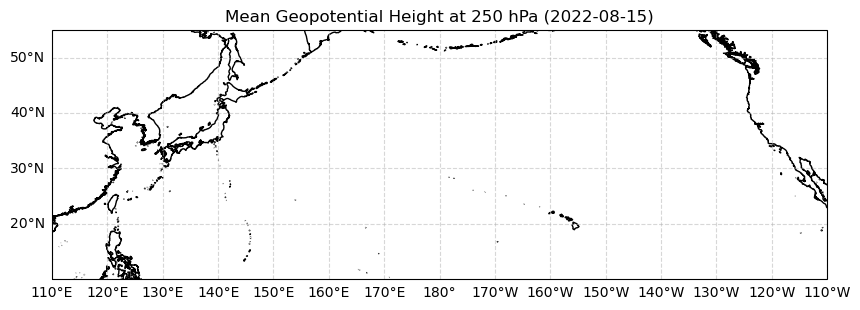

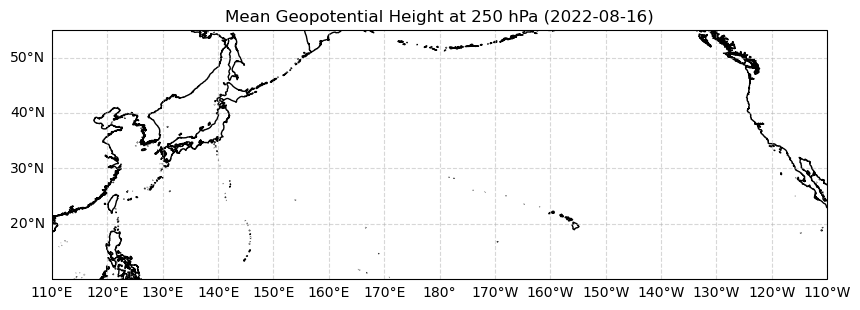

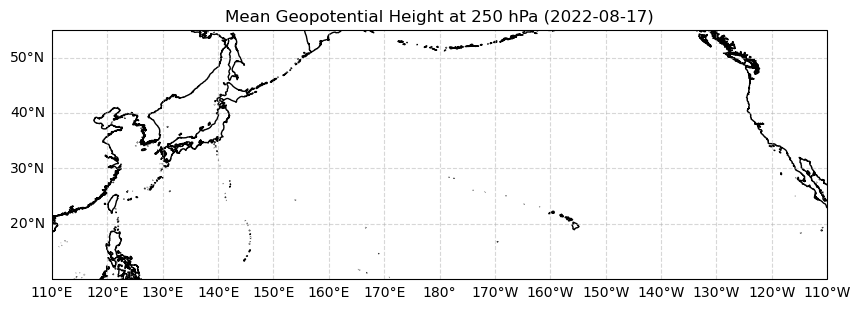

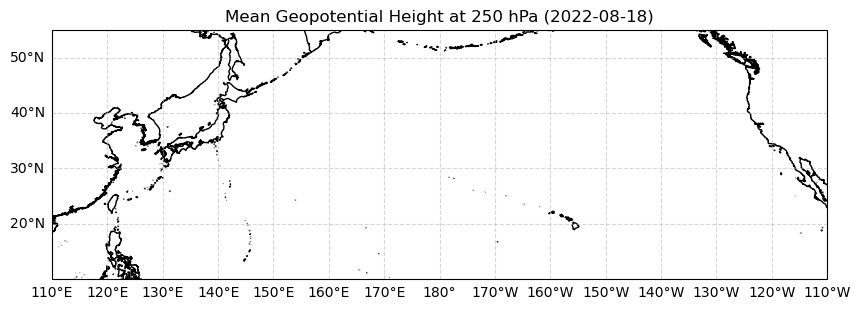

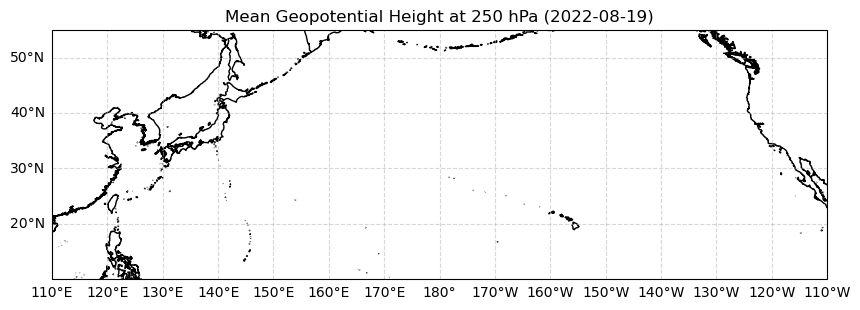

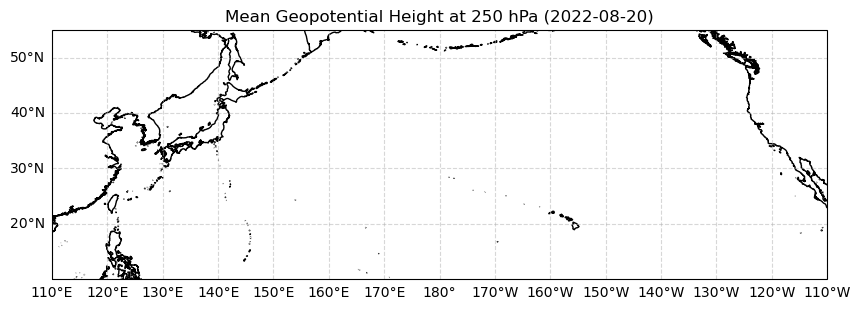

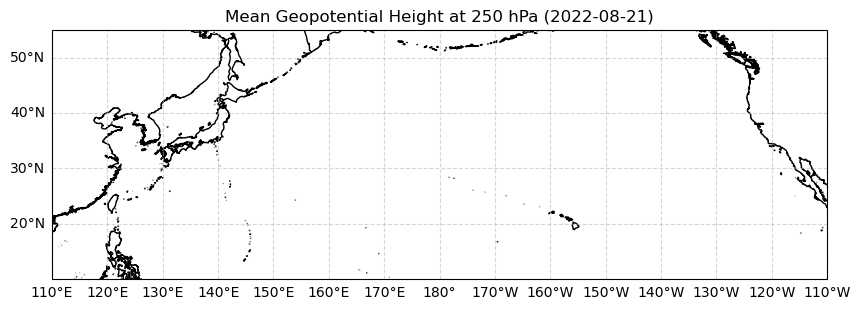

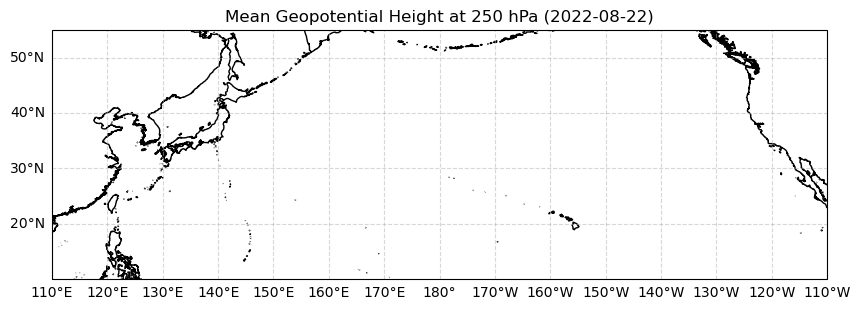

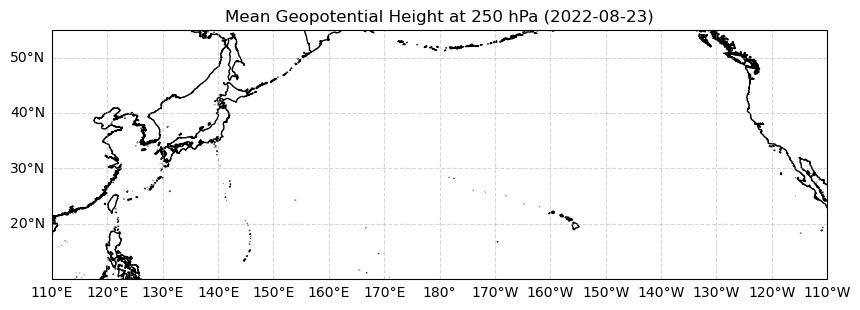

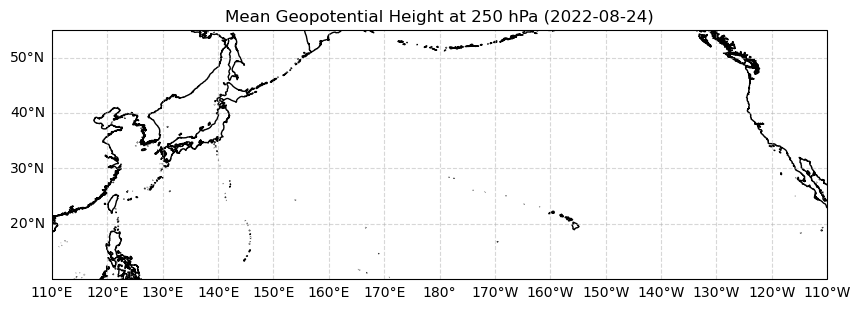

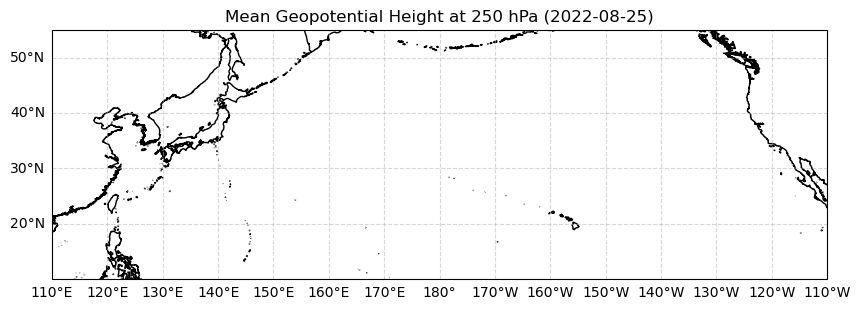

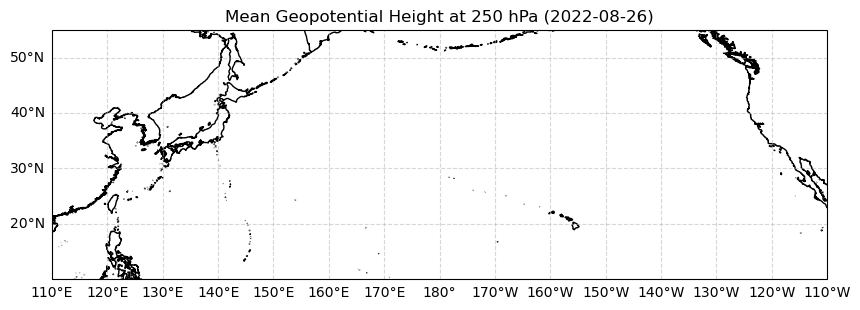

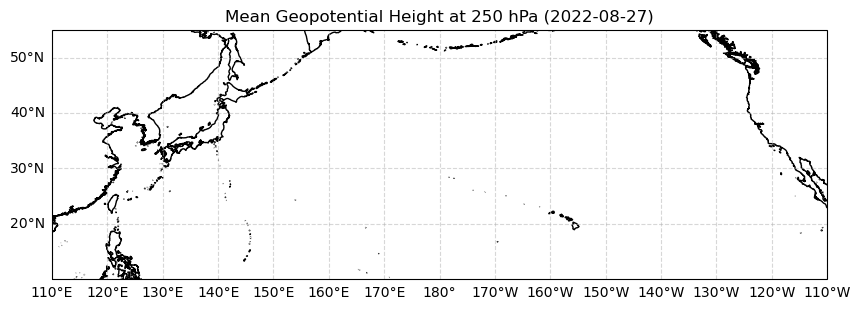

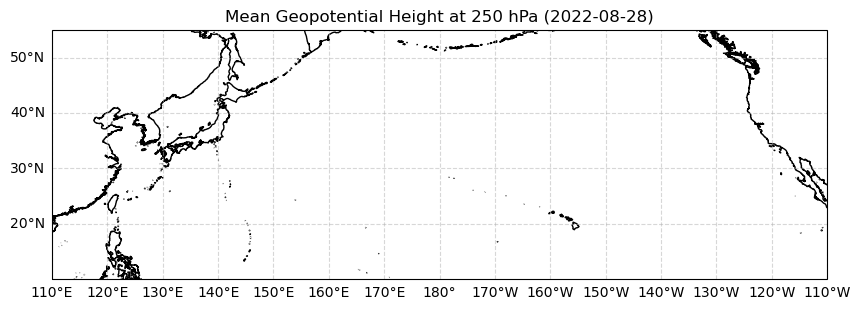

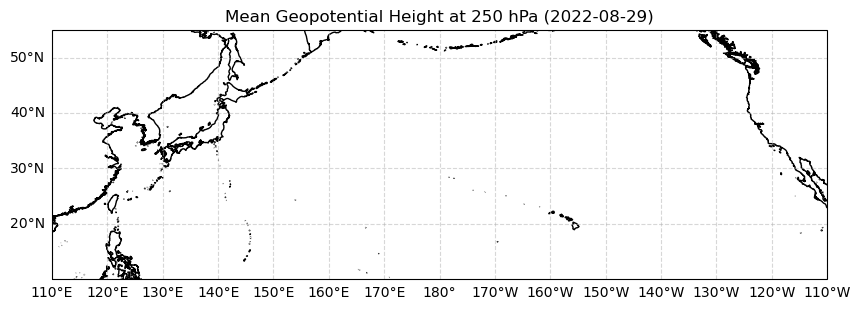

In [6]:
import datetime
G = 9.80665

ds_part = ds[var].sel(pressure_level=250).sel(latitude=slice(55, 10), longitude=slice(110, 280))/G
lon_grid, lat_grid = np.meshgrid(ds_part.longitude.values, ds_part.latitude.values)

key_time = datetime.datetime(2022, 8, 15, 0)
for i in range(15):
    analysis_time = key_time + timedelta(days = i)
    fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree(180)})
    ax.coastlines("10m")
    ax.set_extent([290, 430, 10, 55], crs=ccrs.PlateCarree(180))
    cax = ax.contourf(lon_grid, lat_grid, ds_part.sel(valid_time = analysis_time), levels = np.arange(190, 240, 1), cmap='jet', transform=ccrs.PlateCarree(), linewidths=1)
    cax = ax.contour(lon_grid, lat_grid, ds_part.sel(valid_time = analysis_time), levels = np.arange(190, 240, 1), colors='black', transform=ccrs.PlateCarree(), linewidths=1)
    ax.set_title(f'Mean Geopotential Height at 250 hPa ({analysis_time.strftime("%Y-%m-%d")})')
    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, alpha = 0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xlocator = mticker.FixedLocator(np.arange(-180, 171, 10))
    gl.ylocator = mticker.FixedLocator(np.arange(10, 56, 10))
    plt.show()
